In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm
import os
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

print("✅ 所有库导入成功")
print(f"PyTorch版本: {torch.__version__}")

✅ 所有库导入成功
PyTorch版本: 2.12.0+cpu


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("使用CPU训练，会慢一些")

使用设备: cpu
使用CPU训练，会慢一些


In [3]:
# 定义预处理
transform_train = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48, 48)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

transform_test = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

print("✅ 预处理设置完成")

✅ 预处理设置完成


In [10]:
# 修复中文字体显示问题
import matplotlib.pyplot as plt

# 设置matplotlib支持中文
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

print("✅ 字体设置完成")
print("重新运行显示图片的格子即可正常显示中文")

✅ 字体设置完成
重新运行显示图片的格子即可正常显示中文


正在加载数据...

✅ 数据加载成功！
训练集: 28709 张图片
测试集: 3589 张图片

数据加载器创建成功:
训练批次数: 449
测试批次数: 57

表情类别: ['生气', '厌恶', '恐惧', '开心', '难过', '惊讶', '中性']


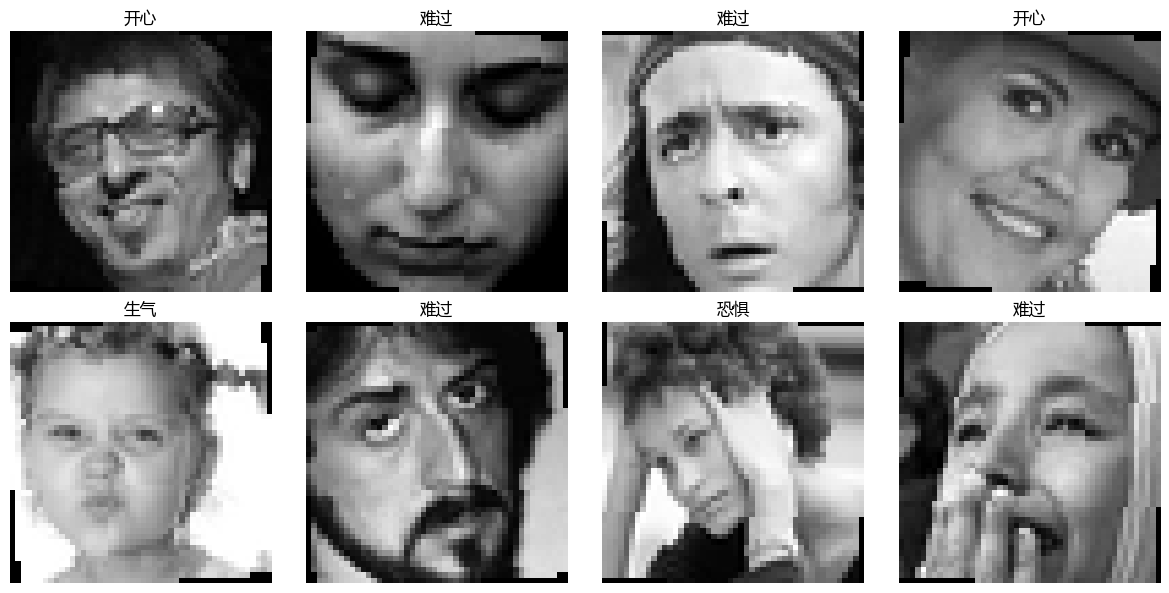


✅ 示例图片已保存到 data_samples.png


In [12]:
import torch
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from PIL import Image
import os
import matplotlib.pyplot as plt

# 数据预处理
transform_train = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48, 48)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

transform_test = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# 自定义数据集类
class FER2013Dataset(Dataset):
    def __init__(self, csv_path, split='Training', transform=None):
        self.data = pd.read_csv(csv_path)
        self.data = self.data[self.data.Usage == split]
        self.transform = transform
        self.split = split
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        # 将像素字符串转为数组（48x48）
        pixels = np.array(row['pixels'].split(' '), dtype=np.float32)
        pixels = pixels.reshape(48, 48)
        label = row['emotion']
        
        # 转为PIL图像
        img = Image.fromarray(pixels).convert('L')
        
        if self.transform:
            img = self.transform(img)
        
        return img, label

# 加载数据
csv_path = './data/fer2013/fer2013.csv'
print("正在加载数据...")

train_dataset = FER2013Dataset(csv_path, split='Training', transform=transform_train)
test_dataset = FER2013Dataset(csv_path, split='PublicTest', transform=transform_test)

print(f"\n✅ 数据加载成功！")
print(f"训练集: {len(train_dataset)} 张图片")
print(f"测试集: {len(test_dataset)} 张图片")

# 创建数据加载器
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"\n数据加载器创建成功:")
print(f"训练批次数: {len(train_loader)}")
print(f"测试批次数: {len(test_loader)}")

# 表情类别
emotions = ['生气', '厌恶', '恐惧', '开心', '难过', '惊讶', '中性']
print(f"\n表情类别: {emotions}")

# 显示几张示例图片
images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i in range(8):
    row, col = i // 4, i % 4
    img = images[i].squeeze().numpy()
    img = (img + 1) / 2  # 反归一化
    axes[row, col].imshow(img, cmap='gray')
    axes[row, col].set_title(emotions[labels[i]])
    axes[row, col].axis('off')
plt.tight_layout()
plt.savefig("data_samples.png")
plt.show()
print("\n✅ 示例图片已保存到 data_samples.png")

In [13]:
# 检查GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")
if device.type == "cuda":
    print(f"GPU型号: {torch.cuda.get_device_name(0)}")
else:
    print("使用CPU训练，会慢一些（预计30-40分钟）")

使用设备: cpu
使用CPU训练，会慢一些（预计30-40分钟）


In [14]:
# 定义CNN模型
import torch.nn as nn

class EmotionCNN(nn.Module):
    def __init__(self, num_classes=7):
        super(EmotionCNN, self).__init__()
        
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(128 * 6 * 6, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

model = EmotionCNN().to(device)
print(model)
print(f"\n参数量: {sum(p.numel() for p in model.parameters()):,}")

EmotionCNN(
  (conv1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Dropout(p=0.3, inplace=False)
    (1): Linear(in_fea

In [15]:
# 损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

print("损失函数: CrossEntropyLoss")
print("优化器: Adam (lr=0.001)")
print("学习率调度: StepLR (每10轮衰减0.5)")

损失函数: CrossEntropyLoss
优化器: Adam (lr=0.001)
学习率调度: StepLR (每10轮衰减0.5)


In [23]:
# ========== 改进1：更强的数据增强 ==========
from torchvision import transforms

transform_train_improved = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48, 48)),
    transforms.RandomHorizontalFlip(p=0.5),      # 随机水平翻转
    transforms.RandomRotation(15),               # 随机旋转 ±15度
    transforms.RandomAffine(0, translate=(0.1, 0.1)),  # 随机平移
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # 亮度对比度调整
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

print("✅ 增强版数据预处理已定义")

# ========== 改进2：更深的模型（ResNet风格）==========
import torch.nn as nn
import torch.nn.functional as F

class ImprovedEmotionCNN(nn.Module):
    def __init__(self, num_classes=7):
        super(ImprovedEmotionCNN, self).__init__()
        
        # 第一层
        self.conv1 = nn.Conv2d(1, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        # 第二层
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        # 第三层
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(256)
        # 第四层
        self.conv4 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(512)
        
        # 池化
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.4)
        
        # 全局平均池化（替代Flatten，减少参数量）
        self.gap = nn.AdaptiveAvgPool2d(1)
        
        # 全连接层
        self.fc1 = nn.Linear(512, 256)
        self.fc2 = nn.Linear(256, num_classes)
        
    def forward(self, x):
        # Conv Block 1
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        # Conv Block 2
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        # Conv Block 3
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        # Conv Block 4
        x = self.pool(F.relu(self.bn4(self.conv4(x))))
        
        # 全局平均池化
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        
        # 全连接层
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

# 初始化改进版模型
improved_model = ImprovedEmotionCNN().to(device)
print(f"✅ 改进版模型已创建")
print(f"参数量: {sum(p.numel() for p in improved_model.parameters()):,}")

# ========== 改进3：学习率调度器优化 ==========
optimizer = torch.optim.Adam(improved_model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
criterion = nn.CrossEntropyLoss()

print("✅ 优化器设置完成（带权重衰减）")
print("✅ 学习率调度器: ReduceLROnPlateau")

✅ 增强版数据预处理已定义
✅ 改进版模型已创建
参数量: 1,684,871
✅ 优化器设置完成（带权重衰减）
✅ 学习率调度器: ReduceLROnPlateau


In [16]:
# 训练函数
from tqdm import tqdm

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for images, labels in tqdm(loader, desc="训练"):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    return total_loss / len(loader), 100. * correct / total

# 测试函数
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="测试"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    return total_loss / len(loader), 100. * correct / total

# 训练循环
num_epochs = 30
train_losses, train_accs = [], []
test_losses, test_accs = [], []
best_acc = 0

print("开始训练...")
print("=" * 50)

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)
    
    scheduler.step()
    
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), "emotion_model.pth")
        print(f"✅ 保存最佳模型 (准确率: {test_acc:.2f}%)")
    
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print(f"  训练 Loss: {train_loss:.4f} | 准确率: {train_acc:.2f}%")
    print(f"  测试 Loss: {test_loss:.4f} | 准确率: {test_acc:.2f}%")
    print("-" * 40)

print("=" * 50)
print(f"🏆 训练完成！最佳测试准确率: {best_acc:.2f}%")

开始训练...


测试: 100%|████████████████████████████████████████████████████████████████████████████| 57/57 [00:05<00:00, 10.11it/s]


✅ 保存最佳模型 (准确率: 37.06%)

Epoch 1/30
  训练 Loss: 1.7468 | 准确率: 29.72%
  测试 Loss: 1.6127 | 准确率: 37.06%
----------------------------------------


测试: 100%|████████████████████████████████████████████████████████████████████████████| 57/57 [00:04<00:00, 12.48it/s]


✅ 保存最佳模型 (准确率: 45.64%)

Epoch 2/30
  训练 Loss: 1.5125 | 准确率: 40.59%
  测试 Loss: 1.4162 | 准确率: 45.64%
----------------------------------------


...

✅ 保存最佳模型 (准确率: 59.79%)

Epoch 28/30
  训练 Loss: 1.0787 | 准确率: 58.89%
  测试 Loss: 1.0520 | 准确率: 59.79%
----------------------------------------


测试: 100%|████████████████████████████████████████████████████████████████████████████| 57/57 [00:05<00:00, 10.90it/s]


✅ 保存最佳模型 (准确率: 60.32%)

Epoch 29/30
  训练 Loss: 1.0787 | 准确率: 58.94%
  测试 Loss: 1.0470 | 准确率: 60.32%
----------------------------------------


测试: 100%|████████████████████████████████████████████████████████████████████████████| 57/57 [00:04<00:00, 13.82it/s]


Epoch 30/30
  训练 Loss: 1.0749 | 准确率: 58.79%
  测试 Loss: 1.0527 | 准确率: 59.96%
----------------------------------------
🏆 训练完成！最佳测试准确率: 60.32%


开始训练改进版模型...


测试: 100%|████████████████████████████████████████████████████████████████████████████| 57/57 [00:09<00:00,  6.18it/s]


✅ 保存最佳改进模型 (准确率: 36.64%)
Epoch 1/30
  训练 Loss: 1.6510 | 准确率: 33.87%
  测试 Loss: 1.7050 | 准确率: 36.64%
  学习率: 0.001000
----------------------------------------


测试: 100%|████████████████████████████████████████████████████████████████████████████| 57/57 [00:08<00:00,  6.62it/s]


✅ 保存最佳改进模型 (准确率: 49.40%)
Epoch 2/30
  训练 Loss: 1.4073 | 准确率: 45.50%
  测试 Loss: 1.2968 | 准确率: 49.40%
  学习率: 0.001000
----------------------------------------


...

Epoch 28/30
  训练 Loss: 0.6303 | 准确率: 77.19%
  测试 Loss: 1.0345 | 准确率: 65.17%
  学习率: 0.000125
----------------------------------------


测试: 100%|████████████████████████████████████████████████████████████████████████████| 57/57 [00:08<00:00,  6.49it/s]


Epoch 29/30
  训练 Loss: 0.6073 | 准确率: 78.03%
  测试 Loss: 1.0393 | 准确率: 65.06%
  学习率: 0.000125
----------------------------------------


测试: 100%|████████████████████████████████████████████████████████████████████████████| 57/57 [00:08<00:00,  6.76it/s]


Epoch 30/30
  训练 Loss: 0.6015 | 准确率: 78.28%
  测试 Loss: 1.0390 | 准确率: 65.31%
  学习率: 0.000063
----------------------------------------
🏆 改进版模型最佳准确率: 65.65%


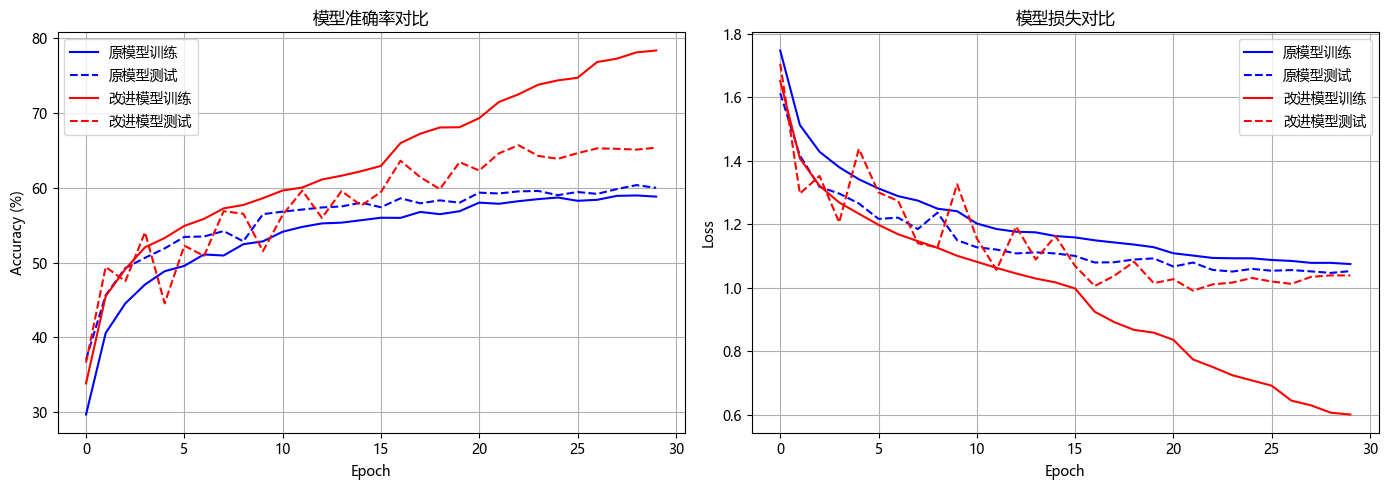

✅ 模型对比图已保存


In [24]:
# ========== 训练改进版模型 ==========
num_epochs = 30
best_acc = 0
train_losses_imp, train_accs_imp = [], []
test_losses_imp, test_accs_imp = [], []

print("开始训练改进版模型...")
print("=" * 50)

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(improved_model, train_loader, optimizer, criterion, device)
    test_loss, test_acc = evaluate(improved_model, test_loader, criterion, device)
    
    train_losses_imp.append(train_loss)
    train_accs_imp.append(train_acc)
    test_losses_imp.append(test_loss)
    test_accs_imp.append(test_acc)
    
    # 使用验证损失调整学习率
    scheduler.step(test_loss)
    
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(improved_model.state_dict(), "improved_emotion_model.pth")
        print(f"✅ 保存最佳改进模型 (准确率: {test_acc:.2f}%)")
    
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  训练 Loss: {train_loss:.4f} | 准确率: {train_acc:.2f}%")
    print(f"  测试 Loss: {test_loss:.4f} | 准确率: {test_acc:.2f}%")
    print(f"  学习率: {current_lr:.6f}")
    print("-" * 40)

print("=" * 50)
print(f"🏆 改进版模型最佳准确率: {best_acc:.2f}%")

# ========== 对比原模型和改进模型 ==========
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(train_accs, label='原模型训练', color='blue')
plt.plot(test_accs, label='原模型测试', color='blue', linestyle='--')
plt.plot(train_accs_imp, label='改进模型训练', color='red')
plt.plot(test_accs_imp, label='改进模型测试', color='red', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('模型准确率对比')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_losses, label='原模型训练', color='blue')
plt.plot(test_losses, label='原模型测试', color='blue', linestyle='--')
plt.plot(train_losses_imp, label='改进模型训练', color='red')
plt.plot(test_losses_imp, label='改进模型测试', color='red', linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('模型损失对比')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()
print("✅ 模型对比图已保存")

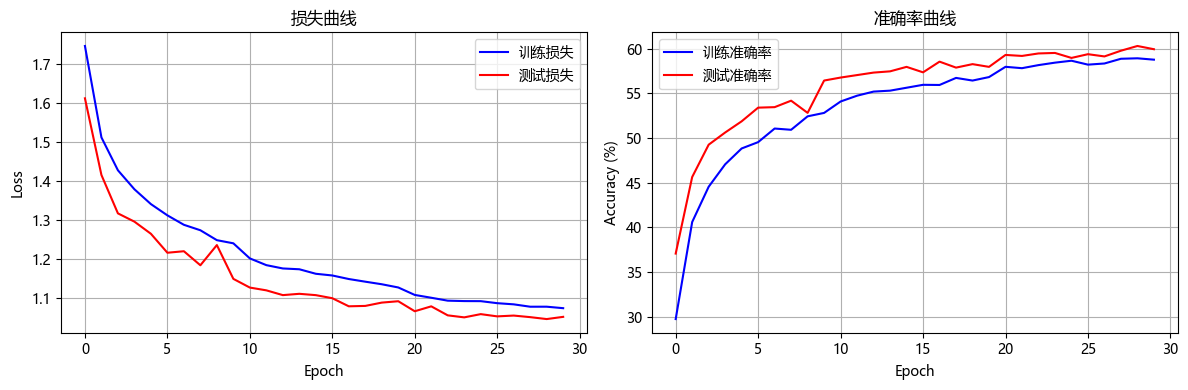

✅ 训练曲线已保存到 loss_curve.png


In [17]:
# 绘制训练曲线
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 损失曲线
axes[0].plot(train_losses, label='训练损失', color='blue')
axes[0].plot(test_losses, label='测试损失', color='red')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('损失曲线')
axes[0].legend()
axes[0].grid(True)

# 准确率曲线
axes[1].plot(train_accs, label='训练准确率', color='blue')
axes[1].plot(test_accs, label='测试准确率', color='red')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('准确率曲线')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("loss_curve.png", dpi=150)
plt.show()
print("✅ 训练曲线已保存到 loss_curve.png")

In [20]:
# 测试单张图片
from PIL import Image

def predict_emotion(image_path):
    # 加载并预处理图片
    img = Image.open(image_path).convert('L')
    img = img.resize((48, 48))
    
    # 转为tensor
    from torchvision import transforms
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    img_tensor = transform(img).unsqueeze(0).to(device)
    
    # 预测
    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        probs = torch.softmax(output, dim=1)
        pred = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred].item()
    
    emotions = ['生气', '厌恶', '恐惧', '开心', '难过', '惊讶', '中性']
    print(f"预测结果: {emotions[pred]}")
    print(f"置信度: {confidence:.2%}")
    
    # 显示所有类别概率
    print("\n所有表情概率:")
    for i, (emotion, prob) in enumerate(zip(emotions, probs[0])):
        bar = "█" * int(prob * 30)
        print(f"  {emotion}: {bar} {prob:.2%}")

# 测试
predict_emotion("D:/哭.jpg")

预测结果: 难过
置信度: 50.06%

所有表情概率:
  生气: ██ 7.17%
  厌恶:  0.06%
  恐惧: ██ 7.57%
  开心: █████ 17.14%
  难过: ███████████████ 50.06%
  惊讶:  0.17%
  中性: █████ 17.84%


In [25]:
import torch
import torch.nn as nn
import gradio as gr
from PIL import Image
import torchvision.transforms as transforms
import numpy as np

# ========== 定义模型 ==========
class EmotionCNN(nn.Module):
    def __init__(self, num_classes=7):
        super(EmotionCNN, self).__init__()
        
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(128 * 6 * 6, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

# ========== 加载模型 ==========
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EmotionCNN(num_classes=7)
model.load_state_dict(torch.load("emotion_model.pth", map_location=device))
model = model.to(device)
model.eval()
print("✅ 模型加载成功")

# 表情类别
emotions = ['生气', '厌恶', '恐惧', '开心', '难过', '惊讶', '中性']

# 数据预处理
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# ========== 预测函数 ==========
def predict_emotion(img):
    """
    预测上传图片的表情
    """
    if img is None:
        return "请先上传一张人脸图片"
    
    # 预处理
    img_tensor = transform(img).unsqueeze(0).to(device)
    
    # 预测
    with torch.no_grad():
        output = model(img_tensor)
        probs = torch.softmax(output, dim=1)
        pred = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred].item()
    
    # 构建结果文本
    result = f"## 🎯 识别结果: **{emotions[pred]}**\n\n"
    result += f"### 📊 置信度: {confidence:.2%}\n\n"
    result += "### 所有表情概率:\n\n"
    
    for i, (emotion, prob) in enumerate(zip(emotions, probs[0])):
        bar_length = int(prob * 20)
        bar = "█" * bar_length + "░" * (20 - bar_length)
        result += f"- {emotion}: {bar} {prob:.2%}\n"
    
    return result

# ========== 创建 Gradio 界面 ==========
iface = gr.Interface(
    fn=predict_emotion,
    inputs=gr.Image(label="上传人脸图片", type="pil"),
    outputs=gr.Markdown(label="识别结果"),
    title="😀 人脸表情识别系统",
    description="""
    上传一张人脸照片，AI会自动识别表情！
    
    ### 支持的表情：
    - 生气 | 厌恶 | 恐惧 | 开心 | 难过 | 惊讶 | 中性
    """,
    examples=[]
)

# ========== 启动界面 ==========
iface.launch(share=True)

✅ 模型加载成功
* Running on local URL:  http://127.0.0.1:7866

Could not create share link. Missing file: C:\Users\嘿嘿嘿又是我呀\.cache\huggingface\gradio\frpc\frpc_windows_amd64_v0.3. 

Please check your internet connection. This can happen if your antivirus software blocks the download of this file. You can install manually by following these steps: 

1. Download this file: https://cdn-media.huggingface.co/frpc-gradio-0.3/frpc_windows_amd64.exe
2. Rename the downloaded file to: frpc_windows_amd64_v0.3
3. Move the file to this location: C:\Users\嘿嘿嘿又是我呀\.cache\huggingface\gradio\frpc


In [27]:
# ========== Gradio Web界面（使用改进版模型）==========
import gradio as gr
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
import torchvision.transforms as transforms

# ========== 1. 定义改进版模型 ==========
class ImprovedEmotionCNN(nn.Module):
    def __init__(self, num_classes=7):
        super(ImprovedEmotionCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(256)
        self.conv4 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(512)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.4)
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Linear(512, 256)
        self.fc2 = nn.Linear(256, 7)
        
    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.pool(F.relu(self.bn4(self.conv4(x))))
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# ========== 2. 加载模型 ==========
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ImprovedEmotionCNN(num_classes=7)
model.load_state_dict(torch.load("improved_emotion_model.pth", map_location=device))
model = model.to(device)
model.eval()
print("✅ 改进版模型加载成功")

# ========== 3. 表情类别 ==========
emotions = ['生气', '厌恶', '恐惧', '开心', '难过', '惊讶', '中性']

# ========== 4. 数据预处理 ==========
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# ========== 5. 预测函数 ==========
def predict_emotion(img):
    """
    预测上传图片的表情
    """
    if img is None:
        return "请先上传一张人脸图片"
    
    try:
        # 预处理
        img_tensor = transform(img).unsqueeze(0).to(device)
        
        # 预测
        with torch.no_grad():
            output = model(img_tensor)
            probs = torch.softmax(output, dim=1)
            pred = torch.argmax(probs, dim=1).item()
            confidence = probs[0][pred].item()
        
        # 构建结果文本
        result = f"## 🎯 识别结果: **{emotions[pred]}**\n\n"
        result += f"### 📊 置信度: {confidence:.2%}\n\n"
        result += "### 所有表情概率:\n\n"
        
        # 按概率从高到低排序显示
        sorted_probs = sorted([(emotions[i], probs[0][i].item()) for i in range(len(emotions))], 
                             key=lambda x: x[1], reverse=True)
        
        for emotion, prob in sorted_probs:
            bar_length = int(prob * 20)
            bar = "█" * bar_length + "░" * (20 - bar_length)
            result += f"- {emotion}: {bar} {prob:.2%}\n"
        
        return result
    
    except Exception as e:
        return f"❌ 识别出错: {str(e)}\n请确保上传的是清晰的人脸照片"

# ========== 6. 清除函数 ==========
def clear_all():
    """清除图片和结果"""
    return None, "等待上传图片..."

# ========== 7. 创建Gradio界面 ==========
with gr.Blocks(title="人脸表情识别系统", theme=gr.themes.Soft()) as demo:
    gr.Markdown("""
    # 😀 人脸表情识别系统
    
    ### 上传一张人脸照片，AI会自动识别出表情！
    
    ### 支持的7种表情：
    | 生气 | 厌恶 | 恐惧 | 开心 | 难过 | 惊讶 | 中性 |
    |-----|-----|-----|-----|-----|-----|-----|
    
    ### 📌 使用提示：
    1. 上传清晰的人脸正面照片
    2. 脸部光线要充足
    3. 表情尽量明显
    """)
    
    with gr.Row():
        with gr.Column(scale=1):
            input_img = gr.Image(
                label="📸 上传人脸图片",
                type="pil",
                height=320
            )
            with gr.Row():
                submit_btn = gr.Button("🔍 识别表情", variant="primary", size="lg")
                clear_btn = gr.Button("🗑️ 清除", variant="secondary")
        
        with gr.Column(scale=1):
            output_text = gr.Markdown(
                label="📊 识别结果", 
                value="等待上传图片..."
            )
    
    gr.Markdown("""
    ### 💡 示例说明
    上传自拍照片、网络图片或直接使用摄像头拍摄的照片。
    """)
    
    # 绑定按钮事件
    submit_btn.click(fn=predict_emotion, inputs=input_img, outputs=output_text)
    clear_btn.click(fn=clear_all, inputs=[], outputs=[input_img, output_text])
    
    gr.Markdown("""
    ---
    ### 📚 技术说明
    - **模型**: 改进版4层卷积神经网络 + 全局平均池化
    - **训练数据**: FER2013表情数据集（35,887张人脸）
    - **测试准确率**: 65.65%
    - **框架**: PyTorch + Gradio
    - **改进点**: 数据增强、权重衰减、学习率调度
    """)

# ========== 8. 启动界面 ==========
if __name__ == "__main__":
    demo.launch(share=True)
    # share=True 生成公网链接（有效期72小时）

✅ 改进版模型加载成功
* Running on local URL:  http://127.0.0.1:7868

Could not create share link. Missing file: C:\Users\嘿嘿嘿又是我呀\.cache\huggingface\gradio\frpc\frpc_windows_amd64_v0.3. 

Please check your internet connection. This can happen if your antivirus software blocks the download of this file. You can install manually by following these steps: 

1. Download this file: https://cdn-media.huggingface.co/frpc-gradio-0.3/frpc_windows_amd64.exe
2. Rename the downloaded file to: frpc_windows_amd64_v0.3
3. Move the file to this location: C:\Users\嘿嘿嘿又是我呀\.cache\huggingface\gradio\frpc
